# BMX Freestyle Judging Analysis

## Measuring judging consistency and disagreement

This notebook analyzes BMX Freestyle judging data collected from RawMotion.

The goal is not to determine whether a judge is "right" or "wrong", but to explore:

- How closely do judges agree?
- Which runs generate the most disagreement?
- Are some judges systematically more generous or conservative?
- Does disagreement increase in certain rounds?
- How much of the final score is driven by judging variation?
- Do judging patterns remain consistent across competitions?

Because RawMotion does not provide judge names, judges are identified by their panel position:

- J1 = Judge 1
- J2 = Judge 2
- J3 = Judge 3
- J4 = Judge 4
- J5 = Judge 5

These identifiers should therefore be interpreted as **judge positions**, not necessarily individual people.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
import time

In [2]:
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

BASE_URL = "https://live.rawmotion.com"
RANDOM_STATE = 42
MIN_JUDGES = 3
JUDGE_COLUMNS = [f"J{i}_score" for i in range(1, 6)]

In [4]:
def get_rawmotion_events():
    session = requests.Session()

    session.headers.update({
        "User-Agent": "Mozilla/5.0",
        "Accept": "text/html,application/xhtml+xml",
    })

    response = session.get(BASE_URL, timeout=20)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    events = []

    for link in soup.find_all("a", href=True):
        href = link["href"]
        text = link.get_text(" ", strip=True)

        if not text:
            continue

        url = urljoin(BASE_URL, href)

        if urlparse(url).netloc != urlparse(BASE_URL).netloc:
            continue

        path = urlparse(url).path.strip("/")

        if not path:
            continue

        events.append({
            "slug": path,
            "url": url,
            "name": text,
        })

    return (
        pd.DataFrame(events)
        .drop_duplicates(subset="url")
        .reset_index(drop=True)
    )


In [5]:
events = get_rawmotion_events()

keywords = [
    "FISE",
    "BMX",
    "BMX FREESTYLE",
    "BMX PARK"
]


mask = events["name"].str.contains(
    "|".join(keywords),
    case=False,
    na=False
)

bmx_events = events[mask].copy()

bmx_events

,slug,url,name
5,fise26birm,https://live.rawmotion.com/fise26birm,2026/08/07 FISE World Series 2026 Birmingham B...
9,AsianBMX2026-1,https://live.rawmotion.com/AsianBMX2026-1,2026/07/11 2026 Asian BMX Freestyle Championsh...
17,mtp26,https://live.rawmotion.com/mtp26,2026/05/16 UCI FISE World Cup Montpellier 2026...
22,fisemac26,https://live.rawmotion.com/fisemac26,2026/03/14 FISE BATTLE OF THE CHAMPIONS MACAO ...
37,fisesak25,https://live.rawmotion.com/fisesak25,2025/11/29 FISE WORLD SERIES SAKAI 2025 Sakai
43,fisesha25,https://live.rawmotion.com/fisesha25,2025/10/17 FISE WORLD SERIES SHANGHAI 2025 Sha...
63,fisemtp25,https://live.rawmotion.com/fisemtp25,2025/05/29 FISE WORLD SERIES MONTPELLIER 2025 ...
87,fisesh24,https://live.rawmotion.com/fisesh24,2024/10/18 FISE Shanghai 2024 Shanghai
110,fisem24,https://live.rawmotion.com/fisem24,2024/05/09 Fise Montpellier 2024 Montpellier
131,FISECHN23,https://live.rawmotion.com/FISECHN23,2023/10/14 FISE Bazhong 2023 Bazhong


In [12]:
class RawmotionEvent:

    BASE_URL = "https://live.rawmotion.com/api/v1"

    def __init__(self, human_event_id, page=None):

        self.human_event_id = human_event_id
        self.page = page or (
            f"https://live.rawmotion.com/{human_event_id}"
        )

        self.session = requests.Session()

        self.session.headers.update({
            "Accept": "application/json",
            "User-Agent": "Mozilla/5.0",
            "Referer": self.page,
        })

        # -----------------------------------------
        # Event metadata
        # -----------------------------------------

        self.event_info = self._get_event_info()

        self.event_id = self.event_info.get("id")
        self.event_name = self.event_info.get("name")

        event_date = self.event_info.get("date", {})

        self.date = event_date.get("start")

        self.location = self.event_info.get("location")

        # -----------------------------------------
        # Contests
        # -----------------------------------------

        self.contests = self._get_contests()


    # =========================================
    # EVENT
    # =========================================

    def _get_event_info(self):

        url = (
            f"{self.BASE_URL}"
            f"/event/{self.human_event_id}/"
        )

        response = self.session.get(
            url,
            timeout=20
        )

        response.raise_for_status()

        data = response.json()

        # API returns a list for this endpoint
        if isinstance(data, list):

            if not data:
                raise ValueError(
                    f"No event found for {self.human_event_id}"
                )

            return data[0]

        return data


    # =========================================
    # CONTESTS
    # =========================================

    def _get_contests(self):

        url = (
            f"{self.BASE_URL}"
            f"/event/{self.event_id}/contests/"
        )

        response = self.session.get(
            url,
            timeout=20
        )

        response.raise_for_status()

        data = response.json()

        if isinstance(data, list):
            return data

        return data.get("contests", [])


    # =========================================
    # CONTEST HELPERS
    # =========================================

    def get_contest(self, name):

        for contest in self.contests:

            if contest.get("name") == name:
                return contest

        return None


    def list_contests(self):

        for contest in self.contests:

            print(
                f'{contest.get("externalId"):>4} | '
                f'{contest.get("state", ""):10} | '
                f'{contest.get("name")}'
            )

            
    def extract_data(self, contest):

        run_rows = []
        judge_rows = []

        contest_name = contest.get("name")

        for category in contest.get("categories", []):

            category_name = category.get("name")

            for round_ in category.get("rounds", []):

                round_name = round_.get("name")

                for heat in round_.get("heats", []):

                    heat_name = heat.get("name")

                    for result in heat.get("results", []):

                        athlete_id = result.get(
                            "externalAthleteId"
                        )

                        athlete = (
                            f'{result.get("firstname", "")} '
                            f'{result.get("lastname", "")}'
                        ).strip()

                        # -----------------------------
                        # Informations communes
                        # -----------------------------

                        base = {
                            "event_id": self.event_id,
                            "event_name": self.event_name,
                            "event_date": self.date,
                            "location": self.location,

                            "contest": contest_name,
                            "category": category_name,
                            "round": round_name,
                            "heat": heat_name,

                            "athlete_id": athlete_id,
                            "athlete": athlete,
                            "firstname": result.get("firstname"),
                            "lastname": result.get("lastname"),
                            "nation": result.get("nation"),
                            "bib": result.get("bib"),

                            "rank": result.get("rank"),

                            "total": self._to_float(
                                result.get("value")
                            ),
                        }

                        # -----------------------------
                        # Runs
                        # -----------------------------

                        runs_detail = next(
                            (
                                d
                                for d in result.get("details", [])
                                if d.get("name") == "Runs"
                            ),
                            None
                        )

                        if not runs_detail:
                            continue

                        for run in runs_detail.get(
                            "details", []
                        ):

                            values = run.get("values", [])

                            if len(values) < 3:
                                continue

                            run_name = values[0]

                            run_score = self._to_float(
                                values[1]
                            )

                            run_valid = (
                                values[2] == "True"
                            )

                            row = base.copy()

                            row.update({
                                "run": run_name,
                                "run_score": run_score,
                                "run_valid": run_valid,

                                "section": (
                                    values[3]
                                    if len(values) > 3
                                    else None
                                ),

                                "is_current": (
                                    values[4] == "True"
                                    if len(values) > 4
                                    else None
                                ),

                                "drop": (
                                    values[5] == "True"
                                    if len(values) > 5
                                    else None
                                ),

                                "penalty": (
                                    values[6] == "True"
                                    if len(values) > 6
                                    else None
                                ),

                                "info": (
                                    values[7]
                                    if len(values) > 7
                                    else None
                                ),
                            })

                            # -------------------------
                            # Notes des juges
                            # -------------------------

                            scores_group = next(
                                (
                                    g
                                    for g in run.get("groups", [])
                                    if g.get("name") == "Scores"
                                ),
                                None
                            )

                            if scores_group:

                                for judge in scores_group.get(
                                    "details", []
                                ):

                                    judge_values = (
                                        judge.get("values", [])
                                    )

                                    if len(judge_values) < 3:
                                        continue

                                    judge_position = (
                                        judge_values[0]
                                    )

                                    score = self._to_float(
                                        judge_values[1]
                                    )

                                    discard = (
                                        judge_values[2] == "True"
                                    )

                                    # DataFrame juges
                                    judge_row = base.copy()

                                    judge_row.update({
                                        "run": run_name,

                                        "run_score": run_score,

                                        "run_valid": run_valid,

                                        "judge_position":
                                            judge_position,

                                        "score": score,

                                        "discard": discard,
                                    })

                                    judge_rows.append(
                                        judge_row
                                    )

                                    # Colonnes J1/J2...
                                    position = (
                                        judge_position
                                        .lower()
                                        .replace("j", "")
                                    )

                                    row[
                                        f"J{position}_score"
                                    ] = score

                                    row[
                                        f"J{position}_discard"
                                    ] = discard

                            run_rows.append(row)

        return (
            pd.DataFrame(run_rows),
            pd.DataFrame(judge_rows)
        )

        # ---------------------------------------------------------

    @staticmethod
    def _to_float(value):

        if value in (None, ""):
            return None

        try:
            return float(value)
        except (ValueError, TypeError):
            return None


In [9]:
def enrich_events(events_df):
    """
    Retrieve detailed metadata for every RawMotion event.

    Parameters
    ----------
    events_df : pd.DataFrame
        Event catalogue containing a 'slug' column.

    Returns
    -------
    pd.DataFrame
        Event metadata.
    """

    rows = []

    for _, event_row in events_df.iterrows():

        human_id = event_row["slug"]

        url = (
            f"{BASE_URL}/api/v1"
            f"/event/{human_id}/"
        )

        try:
            response = requests.get(
                url,
                headers={
                    "Accept": "application/json",
                    "User-Agent": "Mozilla/5.0",
                },
                timeout=20
            )

            response.raise_for_status()

            data = response.json()

            # RawMotion may return a list
            if isinstance(data, list):

                if not data:
                    print(f"❌ Event not found: {human_id}")
                    continue

                metadata = data[0]

            else:
                metadata = data

            date_info = metadata.get("date", {})

            rows.append({

                "human_event_id": human_id,

                "event_id": metadata.get("id"),

                "event_name": metadata.get("name"),

                "date_start": date_info.get("start"),

                "date_end": date_info.get("end"),

                "timezone": metadata.get("timezoneUtc"),

                "sports": metadata.get("sports"),

                "location": metadata.get("location"),

                "url": event_row.get("url"),

            })

            print(
                f"✓ {human_id} | "
                f"{metadata.get('name')}"
            )

        except Exception as e:

            print(
                f"❌ {human_id} | {type(e).__name__}: {e}"
            )

        time.sleep(0.2)

    return pd.DataFrame(rows)


In [10]:
bmx_events_full = enrich_events(bmx_events)

✓ fise26birm | FISE World Series 2026 Birmingham 
✓ AsianBMX2026-1 | 2026 Asian BMX Freestyle Championships
✓ mtp26 | UCI FISE World Cup Montpellier 2026
✓ fisemac26 | FISE BATTLE OF THE CHAMPIONS MACAO 2026
✓ fisesak25 | FISE WORLD SERIES SAKAI 2025
✓ fisesha25 | FISE WORLD SERIES SHANGHAI 2025
✓ fisemtp25 | FISE WORLD SERIES MONTPELLIER 2025
✓ fisesh24 | FISE Shanghai 2024
✓ fisem24 | Fise Montpellier 2024
✓ FISECHN23 | FISE Bazhong 2023
✓ eg23bmf | European Games 2023 - BMX Park
✓ FISE23 | FISE Montpellier 2023
✓ asu22-bmx | ASU 2022 - BMX Freestyle Park
✓ ec2022 | 2022 UEC BMX Park European Championships
✓ FISE22MTP | FISE World Series Montpellier
✓ b49eb2f1-f640-11e9-b83f-15e506f45dec | FISE World Series Chengdu
✓ world-urban-games-2019-BMX | World Urban Games - BMX Freestyle
✓ 890336f1-ab0b-11e9-a3ee-6f3c4245575c | FISE European Series
✓ beaaf3f1-849c-11e9-9e1b-9186e0a55e54 | FISE Montpellier 2019
✓ a76d8371-6a79-11e9-8e68-e7a8406e4723 | FISE Euro Series Madrid
✓ fcff73a1-6256-11

In [11]:
bmx_events_full["date_start"] = pd.to_datetime(
    bmx_events_full["date_start"],
    utc=True
)

bmx_events_full["date_end"] = pd.to_datetime(
    bmx_events_full["date_end"],
    utc=True
)

bmx_events_full["date"] = (
    bmx_events_full["date_start"]
    .dt.date
)

bmx_events_full["year"] = (
    bmx_events_full["date_start"]
    .dt.year
)

bmx_events_full["month"] = (
    bmx_events_full["date_start"]
    .dt.month
)

bmx_events_full[
    [
        "human_event_id",
        "event_id",
        "event_name",
        "date_start",
        "date_end",
        "timezone"
    ]
].sort_values("date_start")


,human_event_id,event_id,event_name,date_start,date_end,timezone
21,b35c40c0-40fa-11e9-85d5-7ff0220f9e3c,b35c40c0-40fa-11e9-85d5-7ff0220f9e3c,FISE Battle of the Champions,2019-03-15 16:58:29.341000+00:00,2019-03-16 16:58:29.341000+00:00,Asia/Amman
20,fcff73a1-6256-11e9-89f4-91465149dd7f,fcff73a1-6256-11e9-89f4-91465149dd7f,FISE World Hiroshima,2019-04-19 03:49:05.359000+00:00,2019-04-21 03:49:05.359000+00:00,Asia/Dili
19,a76d8371-6a79-11e9-8e68-e7a8406e4723,a76d8371-6a79-11e9-8e68-e7a8406e4723,FISE Euro Series Madrid,2019-05-04 12:16:24.779000+00:00,2019-05-05 12:16:24.779000+00:00,Arctic/Longyearbyen
18,beaaf3f1-849c-11e9-9e1b-9186e0a55e54,beaaf3f1-849c-11e9-9e1b-9186e0a55e54,FISE Montpellier 2019,2019-05-30 18:38:15.277000+00:00,2019-06-02 18:38:15.277000+00:00,Arctic/Longyearbyen
17,890336f1-ab0b-11e9-a3ee-6f3c4245575c,890336f1-ab0b-11e9-a3ee-6f3c4245575c,FISE European Series,2019-07-21 06:00:00+00:00,2019-07-21 18:00:00+00:00,Europe/Brussels
16,world-urban-games-2019-BMX,873bc591-ca95-11e9-88fc-7d2eeec68a62,World Urban Games - BMX Freestyle,2019-09-13 08:30:10+00:00,2019-09-15 16:30:10+00:00,Europe/Berlin
15,b49eb2f1-f640-11e9-b83f-15e506f45dec,b49eb2f1-f640-11e9-b83f-15e506f45dec,FISE World Series Chengdu,2019-11-02 04:00:00+00:00,2019-11-03 10:00:00+00:00,Asia/Hong_Kong
14,FISE22MTP,3922b9f1-dc34-11ec-81c5-734c4c845278,FISE World Series Montpellier,2022-05-27 14:02:29+00:00,2022-05-29 14:02:29+00:00,Europe/Berlin
13,ec2022,f65f9291-8d88-11ec-b191-9963409adc1d,2022 UEC BMX Park European Championships,2022-08-11 08:00:00+00:00,2022-08-13 19:00:00+00:00,Europe/Berlin
12,asu22-bmx,de30ec11-44de-11ed-823e-2b34bbb7c72e,ASU 2022 - BMX Freestyle Park,2022-10-08 11:00:00+00:00,2022-10-08 17:00:00+00:00,America/Asuncion


In [120]:
def load_rawmotion_events(events_df):

    loaded_events = {}

    for _, row in events_df.iterrows():

        human_id = row["human_event_id"]

        try:

            event = RawmotionEvent(
                human_id,
                page=row.get("url")
            )

            loaded_events[human_id] = event

            print(
                f"✓ {human_id} | "
                f"{event.event_name}"
            )

        except Exception as e:

            print(
                f"❌ {human_id} | {e}"
            )

    return loaded_events


In [121]:
rawmotion_events = load_rawmotion_events(
    bmx_events_full
)

✓ fise26birm | FISE World Series 2026 Birmingham 
✓ AsianBMX2026-1 | 2026 Asian BMX Freestyle Championships
✓ mtp26 | UCI FISE World Cup Montpellier 2026
❌ fisemac26 | 500 Server Error: Internal Server Error for url: https://live.rawmotion.com/api/v1/event/87ada741-1eb3-11f1-98be-bd00977b8956/contests/
✓ fisesak25 | FISE WORLD SERIES SAKAI 2025
✓ fisesha25 | FISE WORLD SERIES SHANGHAI 2025
✓ fisemtp25 | FISE WORLD SERIES MONTPELLIER 2025
✓ fisesh24 | FISE Shanghai 2024
✓ fisem24 | Fise Montpellier 2024
✓ FISECHN23 | FISE Bazhong 2023
✓ eg23bmf | European Games 2023 - BMX Park
✓ FISE23 | FISE Montpellier 2023
✓ asu22-bmx | ASU 2022 - BMX Freestyle Park
✓ ec2022 | 2022 UEC BMX Park European Championships
✓ FISE22MTP | FISE World Series Montpellier
✓ b49eb2f1-f640-11e9-b83f-15e506f45dec | FISE World Series Chengdu
✓ world-urban-games-2019-BMX | World Urban Games - BMX Freestyle
✓ 890336f1-ab0b-11e9-a3ee-6f3c4245575c | FISE European Series
✓ beaaf3f1-849c-11e9-9e1b-9186e0a55e54 | FISE Mont

In [122]:
def build_contest_catalog(events):

    rows = []

    for human_id, event in events.items():

        for contest in event.contests:

            rows.append({

                "human_event_id": human_id,

                "event_id": event.event_id,

                "event_name": event.event_name,

                "date_start": event.date_start,

                "contest_id": contest.get(
                    "externalId"
                ),

                "contest_name": contest.get(
                    "name"
                ),

                "contest_state": contest.get(
                    "state"
                ),

            })

    return pd.DataFrame(rows)


In [132]:
contests_df = build_contest_catalog(
    rawmotion_events
)

bmx_contests = contests_df[
    contests_df["contest_name"].str.contains("BMX", case=False, na=False)
    & contests_df["contest_name"].str.contains("park", case=False, na=False)
].copy()


bmx_contests[
    [
        "event_name",
        "date_start",
        "contest_name"
    ]
].sort_values("date_start")


,event_name,date_start,contest_name
90,FISE Battle of the Champions,2019-03-15T16:58:29.341Z,BMX PARK PRO
88,FISE World Hiroshima,2019-04-19T03:49:05.359Z,BMX Park Pro
84,FISE World Hiroshima,2019-04-19T03:49:05.359Z,BMX Park Pro Women
83,FISE Euro Series Madrid,2019-05-04T12:16:24.779Z,BMX Park
78,FISE Montpellier 2019,2019-05-30T18:38:15.277Z,BMX Park Pro Women
75,FISE Montpellier 2019,2019-05-30T18:38:15.277Z,BMX Park Pro
72,FISE European Series,2019-07-21T06:00:00.000Z,BMX Freestyle Park
68,FISE World Series Chengdu,2019-11-02T04:00:00.000Z,BMX Park Pro
67,FISE World Series Chengdu,2019-11-02T04:00:00.000Z,BMX Park Pro Women
59,FISE World Series Montpellier,2022-05-27T14:02:29.000Z,BMX Freestyle Park Women


In [134]:
bmx_events_full.to_parquet(
    "rawmotion_events.parquet",
    index=False
)

contests_df.to_parquet(
    "rawmotion_contests.parquet",
    index=False
)

In [ ]:
bmx_events_full = pd.read_parquet(
    "rawmotion_events.parquet"
)

contests_df = pd.read_parquet(
    "rawmotion_contests.parquet"
)

In [166]:
all_runs = []
all_judges = []
errors = []

for i, row in bmx_events.reset_index(drop=True).iterrows():

    slug = row["slug"]

    print(
        f"\n[{i+1}/{len(bmx_events)}] "
        f"{row['name']} ({slug})"
    )

    try:

        event = RawmotionEvent(
            slug,
            page=f"https://live.rawmotion.com/{slug}"
        )

        print(f"    UUID: {event.event_id}")
        print(f"    Event: {event.event_name}")

        for contest in event.contests:

            contest_name = contest.get("name", "")
            contest_upper = contest_name.upper()

            # Keep BMX Park contests only
            if "BMX" not in contest_upper or "PARK" not in contest_upper:
                continue

            print(
                f"    Contest: {contest_name}"
            )

            runs, judges = event.extract_data(
                contest
            )

            if not runs.empty:
                all_runs.append(runs)

            if not judges.empty:
                all_judges.append(judges)

            print(
                f"      Runs: {len(runs):,}"
            )

            print(
                f"      Judge observations: "
                f"{len(judges):,}"
            )

    except Exception as e:

        print(
            f"    ERROR: {type(e).__name__}: {e}"
        )

        errors.append({
            "slug": slug,
            "name": row["name"],
            "error": str(e)
        })



[1/22] 2026/08/07 FISE World Series 2026 Birmingham Birmingham, AL (fise26birm)
    UUID: 3409d461-92a3-11f1-8979-a50a5e5506db
    Event: FISE World Series 2026 Birmingham 
    Contest: UCI BMX FREESTYLE PARK WORLD CUP WOMEN
      Runs: 46
      Judge observations: 230
    Contest: UCI BMX FREESTYLE PARK WORLD CUP MEN
      Runs: 138
      Judge observations: 690

[2/22] 2026/07/11 2026 Asian BMX Freestyle Championships Zigong (AsianBMX2026-1)
    UUID: b4e615a0-7c58-11f1-a1af-8346ef711707
    Event: 2026 Asian BMX Freestyle Championships

[3/22] 2026/05/16 UCI FISE World Cup Montpellier 2026 Montpellier (mtp26)
    UUID: 70ee4051-5103-11f1-9663-5d0d9c10d1a6
    Event: UCI FISE World Cup Montpellier 2026
    Contest: UCI BMX Freestyle Park World Cup Women
      Runs: 50
      Judge observations: 146
    Contest: UCI BMX Freestyle Park World Cup Men
      Runs: 142
      Judge observations: 430

[4/22] 2026/03/14 FISE BATTLE OF THE CHAMPIONS MACAO 2026 Macao (fisemac26)
    ERROR: HTTP

## Competition structure

Before analyzing judging behavior, we first inspect how the competition is organized.

RawMotion separates the competition into:

- contests
- categories
- rounds
- heats
- athletes
- runs
- individual judge scores


In [167]:
runs_df = pd.concat(
    all_runs,
    ignore_index=True
)

judges_df = pd.concat(
    all_judges,
    ignore_index=True
)

print("Runs:", runs_df.shape)
print("Judge observations:", judges_df.shape)


Runs: (2564, 34)
Judge observations: (8402, 23)


In [168]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

runs_df.to_parquet(
    DATA_DIR / "all_bmx_runs.parquet",
    index=False
)

judges_df.to_parquet(
    DATA_DIR / "all_bmx_judges.parquet",
    index=False
)

print("Data saved.")

Data saved.


## 0. Read data

No need to launch every previous cells after you get the data

In [13]:
DATA_DIR = Path("data")

runs_df = pd.read_parquet(DATA_DIR / "all_bmx_runs.parquet")
judges_df = pd.read_parquet(DATA_DIR / "all_bmx_judges.parquet")

print("Data loaded.")
print(f"runs_df   : {runs_df.shape}")
print(f"judges_df : {judges_df.shape}")

Data loaded.
runs_df   : (2564, 34)
judges_df : (8402, 23)


## 1. Cleaning data

Before drawing conclusions, we check the property of the dataset.

In [19]:
judge_columns = [
    "J1_score",
    "J2_score",
    "J3_score",
    "J4_score",
    "J5_score"
]

runs_df[judge_columns].isna().sum()

J1_score       0
J2_score     891
J3_score     891
J4_score    1154
J5_score    1394
dtype: int64

In [24]:
runs_df["number_of_judges"] = (
    runs_df[judge_columns]
    .notna()
    .sum(axis=1)
)

runs_df["number_of_judges"].value_counts()

number_of_judges
5    1126
1     891
3     263
4     240
Name: count, dtype: int64

In [25]:
key_cols = [
    "event_id",
    "contest",
    "category",
    "round",
    "heat",
    "athlete_id",
    "run"
]

# Nombre de lignes avant
before = len(runs_df)

# Suppression des doublons
runs_df = runs_df.drop_duplicates(
    subset=key_cols,
    keep="first"
).reset_index(drop=True)

# Nombre de lignes après
after = len(runs_df)

print(f"Removed {before - after:,} duplicates.")
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")

Removed 0 duplicates.
Rows before: 2,520
Rows after:  2,520


In [26]:
judge_key = [
    "event_id",
    "contest",
    "category",
    "round",
    "heat",
    "athlete_id",
    "run",
    "judge_position"
]

before = len(judges_df)

judges_df = judges_df.drop_duplicates(
    subset=judge_key,
    keep="first"
).reset_index(drop=True)

after = len(judges_df)

print(f"Removed {before - after:,} duplicates.")
print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")

Removed 0 duplicates.
Rows before: 8,270
Rows after:  8,270


In [46]:
def normalize_round(x):
    x = str(x).strip().upper()

    if x in ["FINAL", "PRO FINAL"]:
        return "Final"
    elif x == "SEMI FINAL":
        return "Semi Final"
    else:
        return "Qualification"


runs_df["round"] = runs_df["round"].apply(normalize_round)

In [57]:
runs_df = runs_df[
    runs_df["athlete"].notna()
    & runs_df["athlete"].str.strip().ne("")
].reset_index(drop=True)

In [58]:
analysis_df = runs_df[
    runs_df["number_of_judges"] >= 3
].copy()

complete_judge_df = runs_df[
    runs_df[judge_columns].notna().all(axis=1)
].copy()

## 2. How much do judges disagree?

For each run, we measure the dispersion of the five scores.

Three simple measures are useful:

- Mean score: the average assessment of the panel
- Spread: highest score minus lowest score
- Standard deviation: overall dispersion around the panel mean

A large spread does not mean that a judge made a mistake.

It simply means that the panel perceived the performance differently.


In [59]:
analysis_df["panel_mean"] = analysis_df[judge_columns].mean(axis=1)

analysis_df["judge_min"] = analysis_df[judge_columns].min(axis=1)

analysis_df["judge_max"] = analysis_df[judge_columns].max(axis=1)

analysis_df["judge_spread"] = (
    analysis_df["judge_max"]
    - analysis_df["judge_min"]
)

analysis_df["judge_std"] = (
    analysis_df[judge_columns]
    .std(axis=1, ddof=0)
)

analysis_df["judge_mad"] = (
    analysis_df[judge_columns]
    .sub(runs_df[judge_columns].mean(axis=1), axis=0)
    .abs()
    .mean(axis=1)
)

Is disagreement generally small, or are there many runs where judges see the performance very differently?

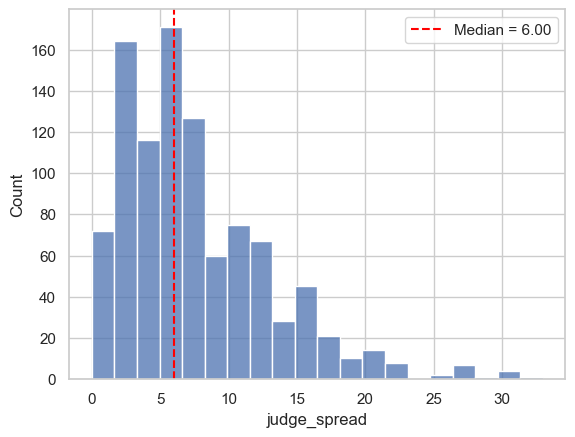

In [60]:
median_spread = analysis_df["judge_spread"].median()

sns.histplot(
    data=analysis_df,
    x="judge_spread",
    bins=20
)

plt.axvline(
    median_spread,
    color="red",
    linestyle="--",
    label=f"Median = {median_spread:.2f}"
)

plt.legend()
plt.show()

Which rounds generate the most disagreement?

In [61]:
round_disagreement = (
    analysis_df
    .groupby([
        "event_name",
        "contest",
        "category",
        "round"
    ])
    .agg(
        runs=("judge_spread", "count"),
        mean_spread=("judge_spread", "mean"),
        median_spread=("judge_spread", "median"),
        max_spread=("judge_spread", "max"),
    )
    .reset_index()
)

In [62]:
round_disagreement

,event_name,contest,category,round,runs,mean_spread,median_spread,max_spread
0,European Games 2023 - BMX Park,Men´s BMX Freestyle Park,Default,Final,24,2.962500,2.25,7.9
1,European Games 2023 - BMX Park,Men´s BMX Freestyle Park,Default,Qualification,57,2.392982,2.00,9.0
2,European Games 2023 - BMX Park,Women´s BMX Freestyle Park,Default,Final,22,3.909091,3.00,14.0
3,European Games 2023 - BMX Park,Women´s BMX Freestyle Park,Default,Qualification,30,3.016667,2.00,7.0
4,FISE Bazhong 2023,UCI BMX FREESTYLE PARK WC,Default,Final,24,4.995833,3.50,22.5
5,FISE Bazhong 2023,UCI BMX FREESTYLE PARK WC,Default,Semi Final,48,9.260417,7.75,31.0
6,FISE Bazhong 2023,UCI BMX FREESTYLE PARK WC WOMEN,Default,Final,24,7.554167,6.75,27.0
7,FISE Montpellier 2023,UCI BMX FREESTYLE PARK WC,Default,Semi Final,48,8.541667,7.00,21.0
8,FISE Montpellier 2023,UCI BMX FREESTYLE PARK WC WOMEN,Default,Final,24,13.125000,13.00,27.0
9,FISE Shanghai 2024,UCI BMX PARK WC,Default,Qualification,84,10.132857,9.00,31.0


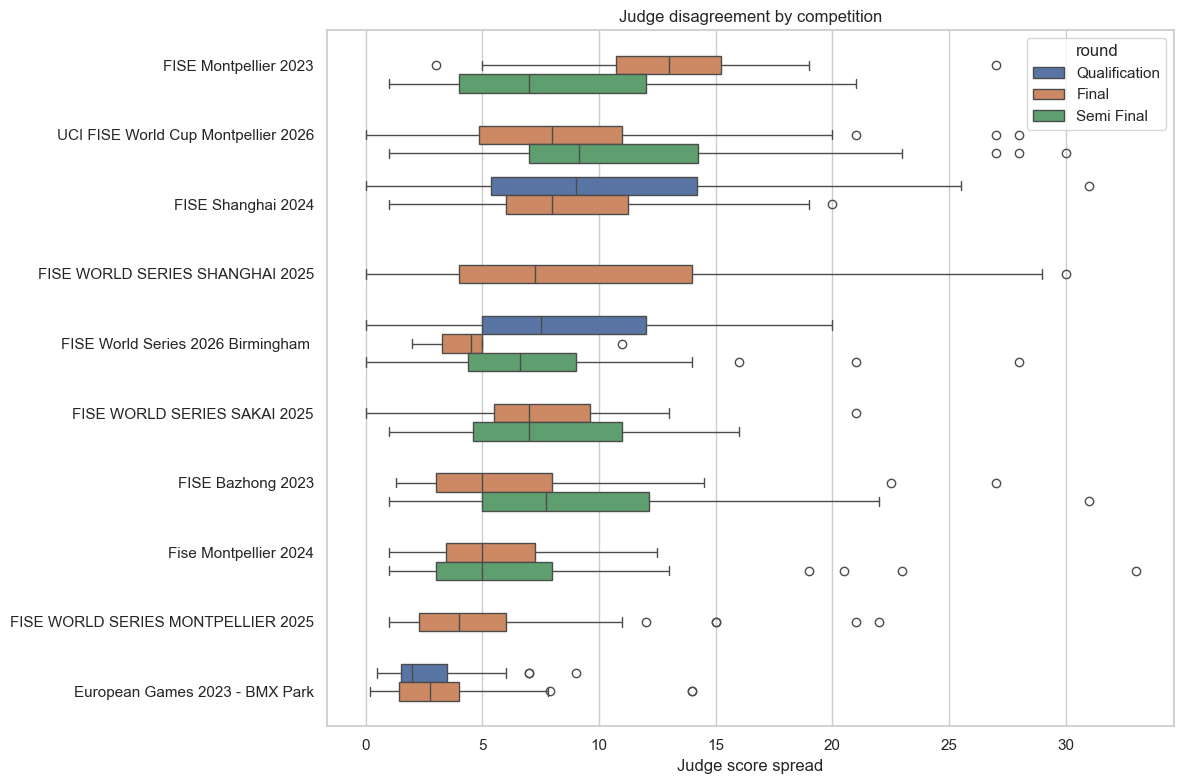

In [63]:
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=analysis_df,
    y="event_name",
    x="judge_spread",
    hue="round",
    order=(
        analysis_df.groupby("event_name")["judge_spread"]
        .median()
        .sort_values(ascending=False)
        .index
    )
)

plt.ylabel("")
plt.xlabel("Judge score spread")
plt.title("Judge disagreement by competition")

plt.tight_layout()
plt.show()


In [64]:
controversial = (
    analysis_df
    .sort_values(
        "judge_spread",
        ascending=False
    )
)

controversial[
    [
        "event_name",
        "round",
        "heat",
        "athlete",
        "run",
        "run_score",
        "J1_score",
        "J2_score",
        "J3_score",
        "J4_score",
        "J5_score",
        "judge_spread",
        "panel_mean"
    ]
].head(20)


,event_name,round,heat,athlete,run,run_score,J1_score,J2_score,J3_score,J4_score,J5_score,judge_spread,panel_mean
1002,Fise Montpellier 2024,Semi Final,Main,Declan BROOKS,Run 2,34.25,43.0,42.0,42.0,10.0,NaN,33.0,34.25
1247,FISE Bazhong 2023,Semi Final,Main,Joji MIZOGAKI,Run 1,33.40,32.0,35.0,53.0,22.0,25.0,31.0,33.40
900,FISE Shanghai 2024,Qualification,Main,Jeffrey WHALEY,Run 2,59.00,62.0,75.0,69.0,44.0,45.0,31.0,59.00
544,FISE WORLD SERIES SHANGHAI 2025,Final,Main,Hannah ROBERTS,Run 2,39.60,42.0,60.0,36.0,30.0,30.0,30.0,39.60
325,UCI FISE World Cup Montpellier 2026,Semi Final,Main,Aliev ANAR,Run 2,47.80,67.0,49.0,44.0,42.0,37.0,30.0,47.80
621,FISE WORLD SERIES SHANGHAI 2025,Final,Main,Shaun GORNALL,Run 2,54.80,60.0,69.0,49.0,56.0,40.0,29.0,54.80
309,UCI FISE World Cup Montpellier 2026,Semi Final,Main,Marcus CHRISTOPHER,Run 2,53.00,70.0,47.0,42.0,49.0,57.0,28.0,53.00
143,FISE World Series 2026 Birmingham,Semi Final,Main,Marcus CHRISTOPHER,Run 2,25.80,41.0,26.0,19.0,13.0,30.0,28.0,25.80
211,UCI FISE World Cup Montpellier 2026,Final,Main,Rena SHIRAI,Run 2,51.40,35.0,51.0,58.0,50.0,63.0,28.0,51.40
334,UCI FISE World Cup Montpellier 2026,Semi Final,Main,Nick BRUCE,Run 1,30.60,18.0,25.0,27.0,38.0,45.0,27.0,30.60


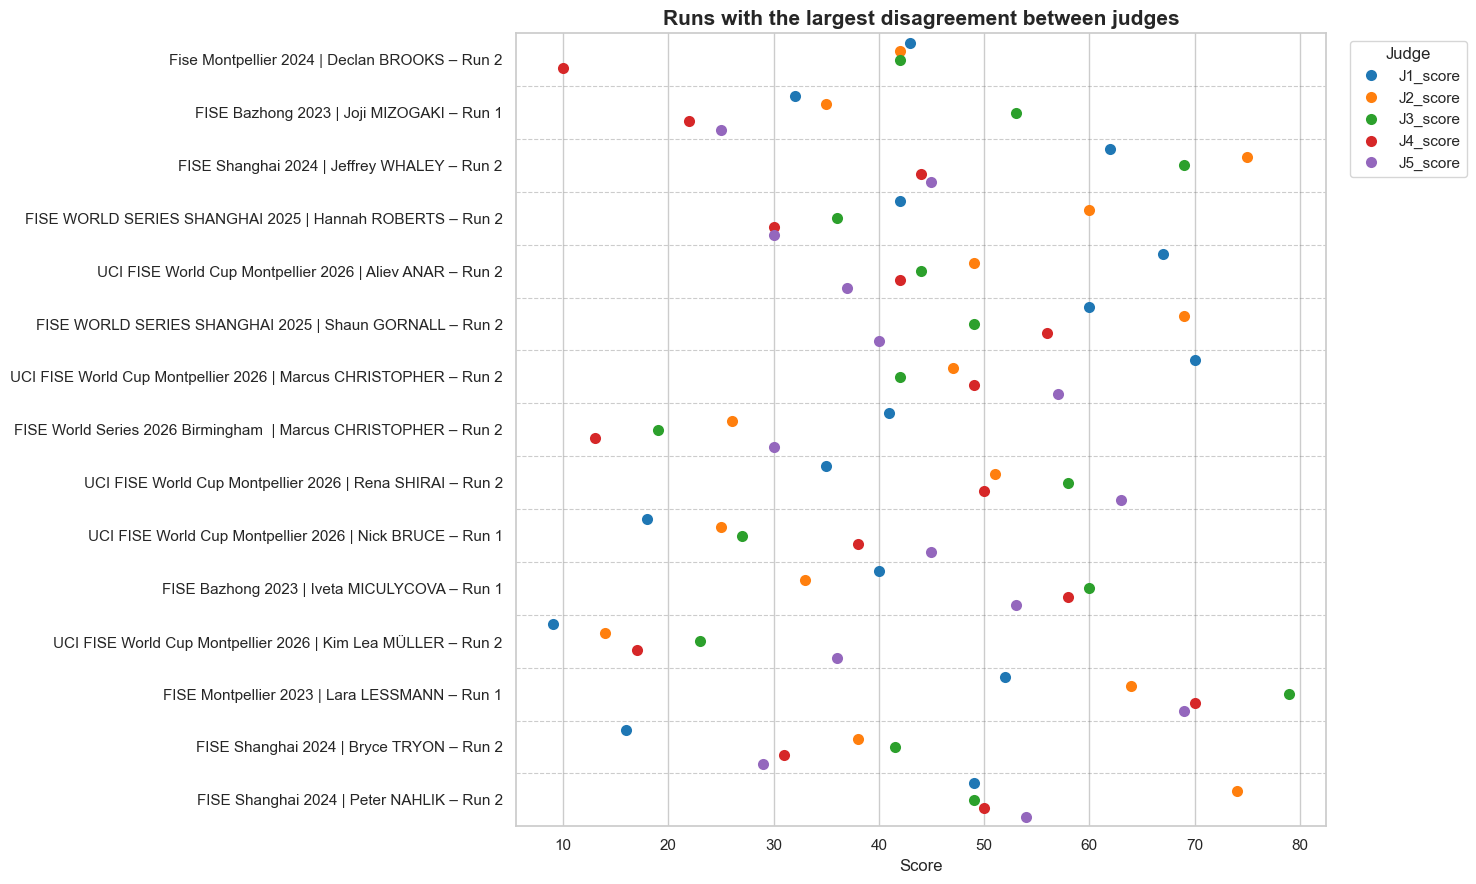

In [65]:
top = controversial.head(15).copy()

top["label"] = (
    top["event_name"]
    + " | "
    + top["athlete"]
    + " – "
    + top["run"]
)

plot_df = top.melt(
    id_vars=["label", "event_name", "judge_spread"],
    value_vars=judge_columns,
    var_name="judge",
    value_name="score"
)

plt.figure(figsize=(15, 9))

# Palette très contrastée
palette = sns.color_palette("tab10", n_colors=len(judge_columns))

ax = sns.stripplot(
    data=plot_df,
    x="score",
    y="label",
    hue="judge",
    dodge=True,
    size=8,
    palette=palette
)

# Lignes horizontales entre les runs
for y in range(len(top) - 1):
    ax.axhline(
        y=y + 0.5,
        color="gray",
        linestyle="--",
        linewidth=0.8,
        alpha=0.4
    )

ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_title(
    "Runs with the largest disagreement between judges",
    fontsize=15,
    fontweight="bold"
)

ax.legend(
    title="Judge",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 3. Do some judges systematically score higher or lower?

Because there is no objective "correct" score, we cannot measure absolute judging accuracy.

Instead, we compare each judge with the other four judges.

For each run:

Judge deviation = judge score − mean score of the other judges

A positive value means the judge scored higher than the rest of the panel.

A negative value means the judge scored lower.


In [66]:
for judge in judge_columns:

    others = [
        j for j in judge_columns
        if j != judge
    ]

    runs_df[f"{judge}_others_mean"] = (
        runs_df[others].mean(axis=1)
    )

    runs_df[f"{judge}_deviation"] = (
        runs_df[judge]
        - runs_df[f"{judge}_others_mean"]
    )


In [67]:
summary = []

for event_name, event_df in runs_df.groupby("event_name"):

    for judge in judge_columns:

        deviation = event_df[f"{judge}_deviation"]

        summary.append({
            "event_name": event_name,
            "judge": judge.replace("_score", ""),
            "mean_deviation": deviation.mean(),
            "median_deviation": deviation.median(),
            "mean_absolute_deviation": deviation.abs().mean(),
            "std_deviation": deviation.std(),
        })

judge_summary = (
    pd.DataFrame(summary)
    .sort_values(
        ["event_name", "mean_absolute_deviation"],
        ascending=[True, False]
    )
)

judge_summary


C:\Users\USER\.conda\envs\footy\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\USER\.conda\envs\footy\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\USER\.conda\envs\footy\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,event_name,judge,mean_deviation,median_deviation,mean_absolute_deviation,std_deviation
2,European Games 2023 - BMX Park,J3,0.511654,0.500000,1.833459,2.351111
1,European Games 2023 - BMX Park,J2,-0.659023,-0.750000,1.736466,2.334092
0,European Games 2023 - BMX Park,J1,0.147368,0.000000,1.402256,2.080868
3,European Games 2023 - BMX Park,J4,NaN,NaN,NaN,NaN
4,European Games 2023 - BMX Park,J5,NaN,NaN,NaN,NaN
5,FISE Bazhong 2023,J1,0.891406,1.187500,3.207031,4.229723
7,FISE Bazhong 2023,J3,1.200000,0.750000,3.122656,4.466345
9,FISE Bazhong 2023,J5,-1.202995,-0.125000,3.089453,4.236096
6,FISE Bazhong 2023,J2,0.122526,-0.250000,3.061328,4.937520
8,FISE Bazhong 2023,J4,-1.010938,-0.737500,2.543750,3.595212


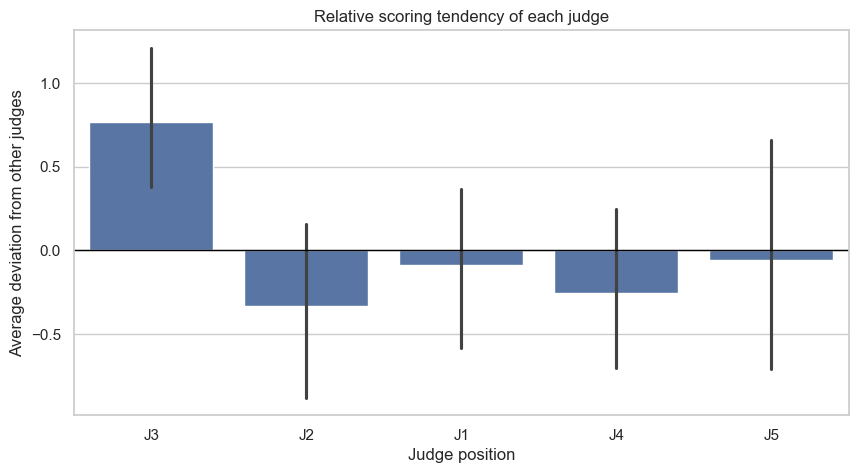

In [69]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=judge_summary,
    x="judge",
    y="mean_deviation"
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.ylabel(
    "Average deviation from other judges"
)

plt.xlabel("Judge position")

plt.title(
    "Relative scoring tendency of each judge"
)

plt.show()


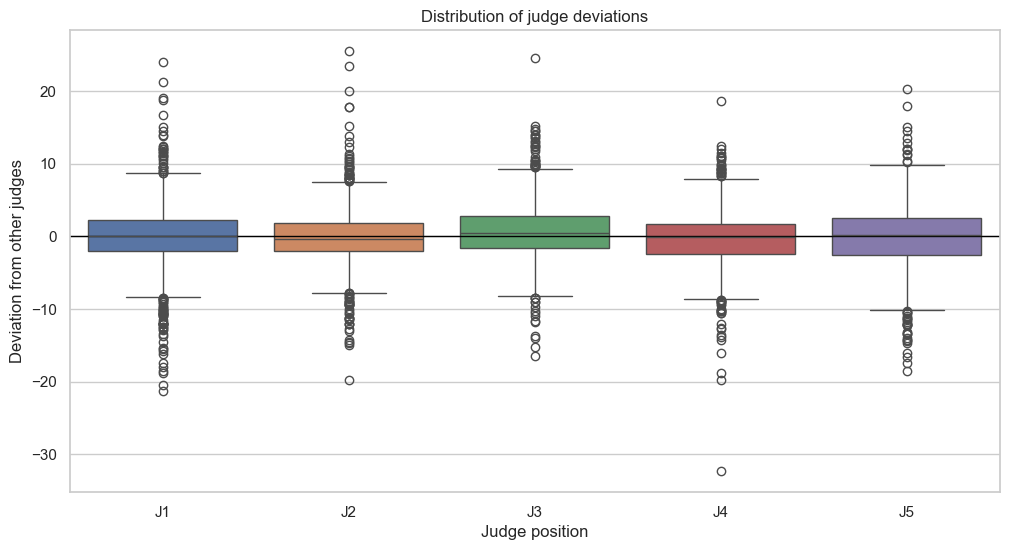

In [70]:
deviation_columns = [
    f"{j}_deviation"
    for j in judge_columns
]

deviation_df = runs_df[
    deviation_columns
].copy()

deviation_df.columns = [
    j.replace("_score", "")
    for j in judge_columns
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=deviation_df
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.ylabel(
    "Deviation from other judges"
)

plt.xlabel("Judge position")

plt.title(
    "Distribution of judge deviations"
)

plt.show()


In [71]:
for judge in judge_columns:

    deviation = runs_df[
        f"{judge}_deviation"
    ]

    print(
        judge,
        "largest positive:",
        deviation.max(),
        "largest negative:",
        deviation.min()
    )


J1_score largest positive: 24.0 largest negative: -21.25
J2_score largest positive: 25.5 largest negative: -19.75
J3_score largest positive: 24.5 largest negative: -16.5
J4_score largest positive: 18.66666666666667 largest negative: -32.333333333333336
J5_score largest positive: 20.25 largest negative: -18.5


## 4. Do judges rank performances similarly?

Correlation measures whether judges tend to move in the same direction.

A high correlation means that when one judge gives relatively high scores, the other judge tends to do so as well.

However, correlation does not mean that judges give the same scores.

Two judges can have a correlation of 0.95 while one consistently scores two points higher.
Spearman correlation measures similarity in relative ordering, not agreement in absolute scores.


In [73]:
correlation_matrices = {}

for event_name, event_df in runs_df.groupby("event_name"):

    correlation_matrices[event_name] = (
        event_df[judge_columns]
        .corr(method="spearman")
    )


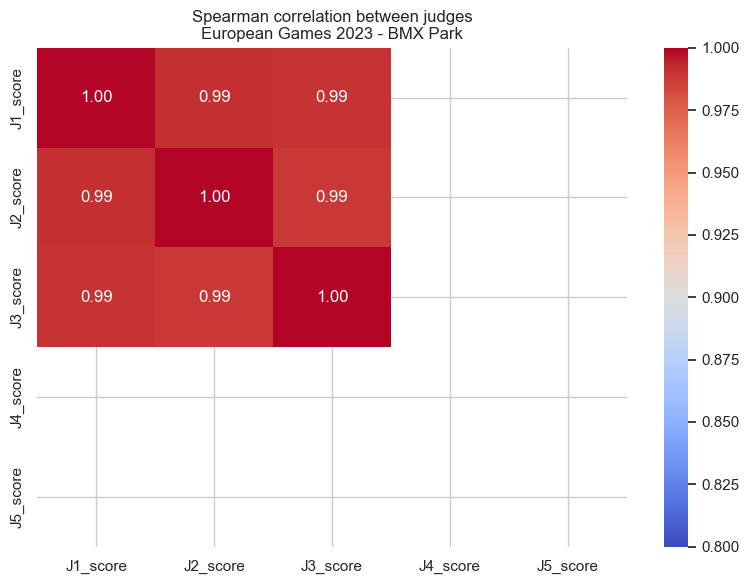

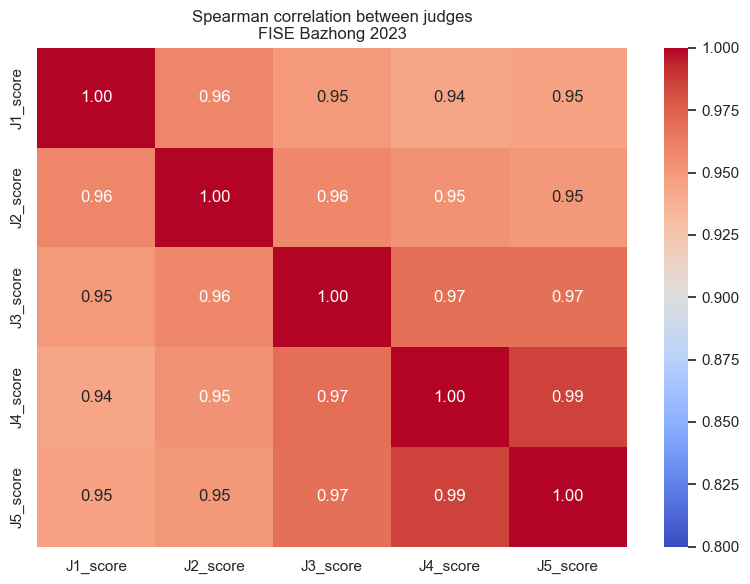

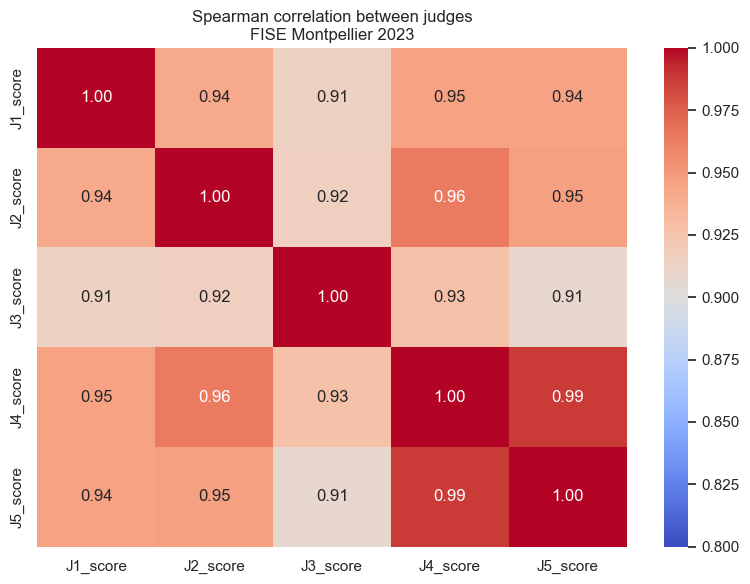

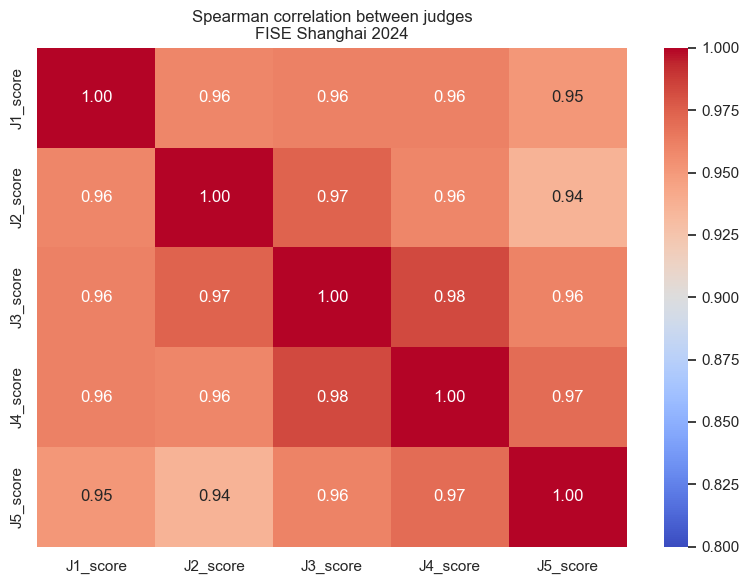

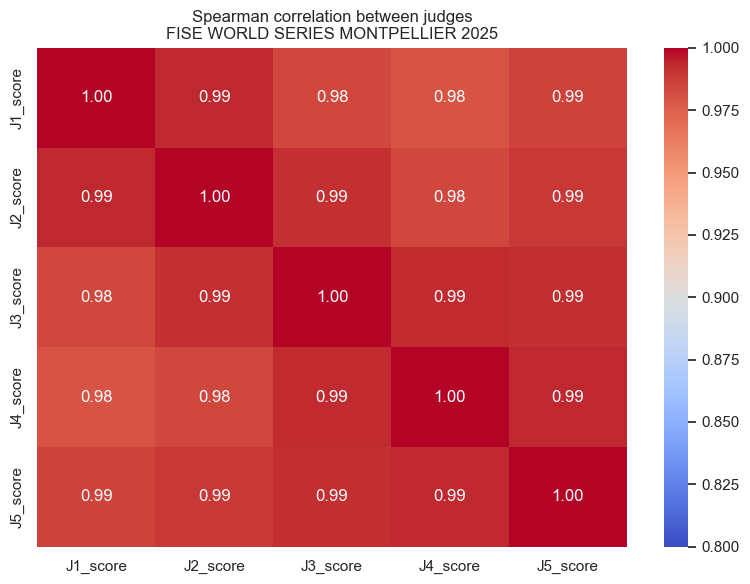

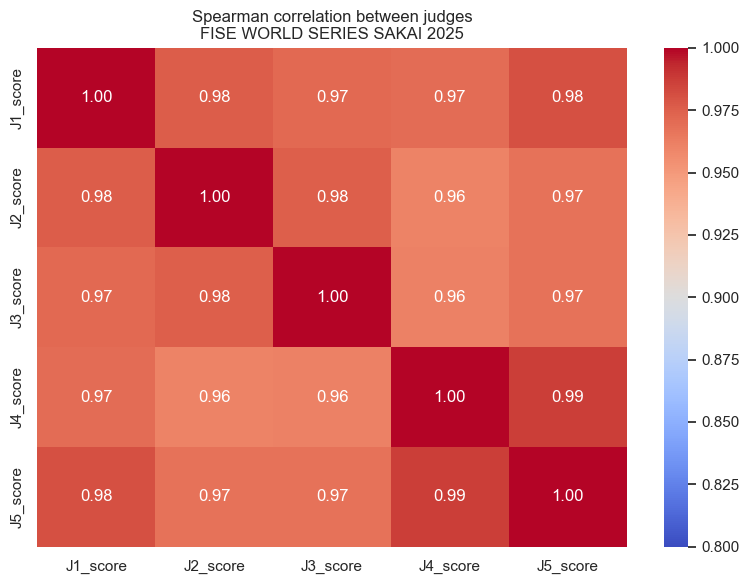

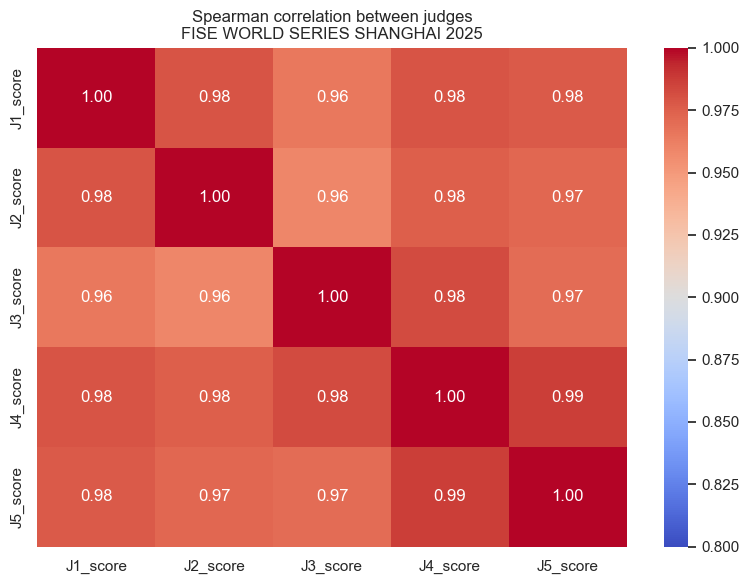

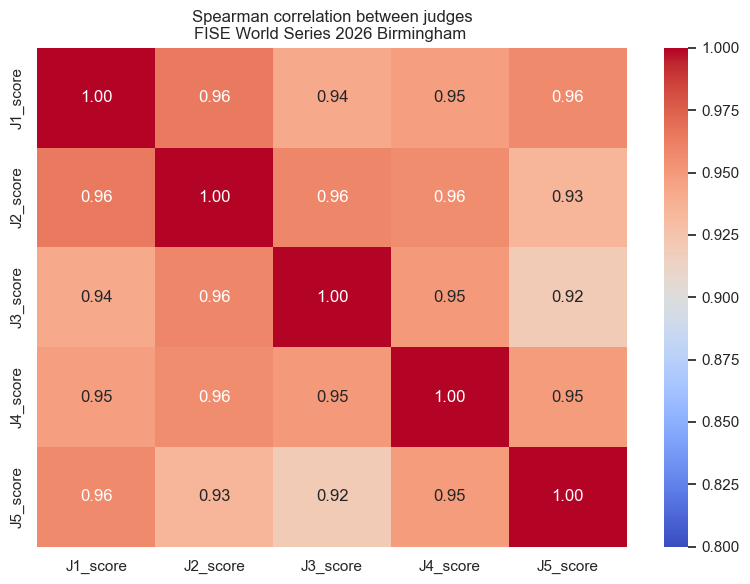

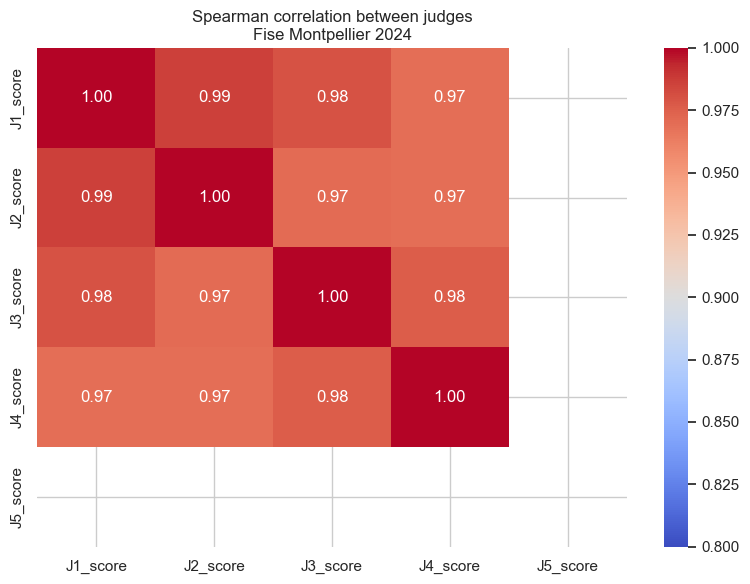

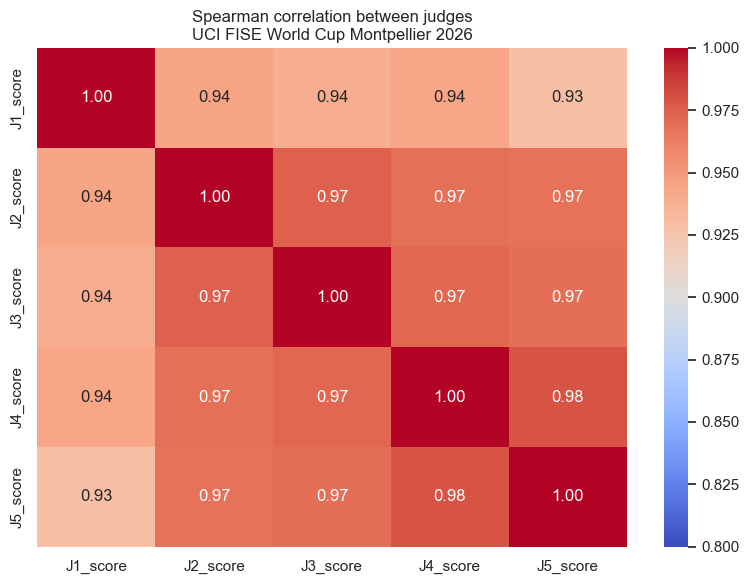

In [74]:
for event_name, correlation_matrix in correlation_matrices.items():

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=0.8,
        vmax=1
    )

    plt.title(
        f"Spearman correlation between judges\n{event_name}"
    )

    plt.tight_layout()
    plt.show()


## 5. Does judging disagreement affect the ranking?

A run can receive very different scores from the judges while still receiving a high or low panel average.

This section examines two related questions:

1. Does judging disagreement increase or decrease depending on the score level?
2. How sensitive are rankings to individual judges' scores?

The first question is descriptive: we compare the panel mean with the spread between judges.

The second question is more directly related to competitive impact. We perform a leave-one-judge-out analysis: for each run, we recalculate the panel score after removing one judge at a time.

Because official rankings depend on the scoring system used by the competition, the leave-one-judge-out analysis is primarily a sensitivity analysis rather than a reconstruction of the official ranking procedure.

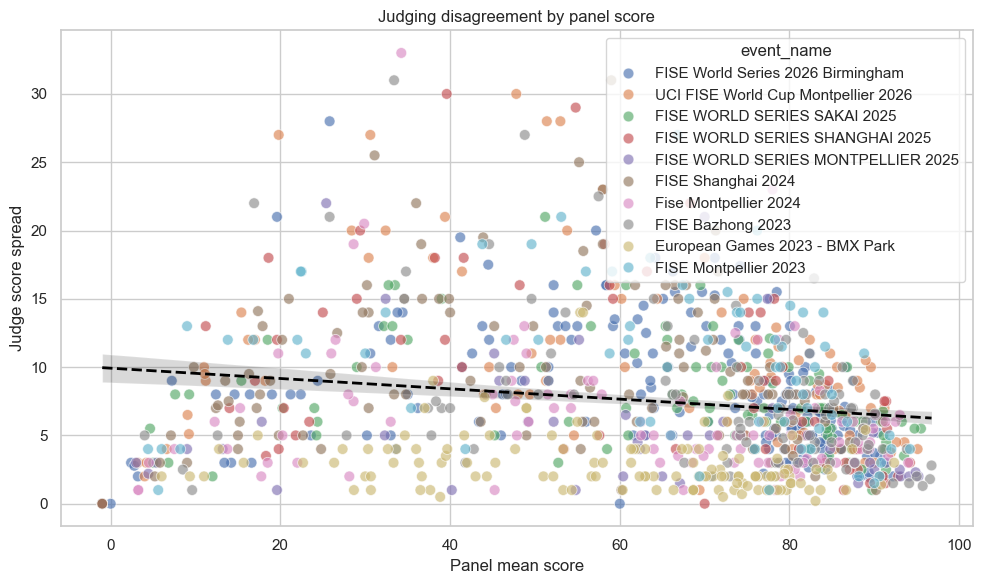

In [78]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=analysis_df,
    x="panel_mean",
    y="judge_spread",
    hue="event_name",
    alpha=0.65,
    s=60
)

sns.regplot(
    data=analysis_df,
    x="panel_mean",
    y="judge_spread",
    scatter=False,
    color="black",
    line_kws={
        "linewidth": 2,
        "linestyle": "--"
    }
)

plt.xlabel("Panel mean score")
plt.ylabel("Judge score spread")
plt.title(
    "Judging disagreement by panel score"
)

plt.tight_layout()
plt.show()

In [79]:
score_spread_corr = analysis_df[
    ["panel_mean", "judge_spread"]
].corr(method="spearman").loc[
    "panel_mean",
    "judge_spread"
]

print(
    f"Spearman correlation between panel score "
    f"and judge disagreement: {score_spread_corr:.3f}"
)

Spearman correlation between panel score and judge disagreement: -0.227


The disagreement tend to decrease the score

In [87]:
analysis_df["relative_disagreement"] = (
    analysis_df["judge_spread"]
    / analysis_df["panel_mean"]
)

result = (
    analysis_df[analysis_df["panel_mean"] > 60]
    [
        [
            "event_name",
            "round",
            "athlete",
            "run",
            "panel_mean",
            "judge_spread",
            "relative_disagreement"
        ]
    ]
)

result.sort_values(
    "relative_disagreement",
    ascending=False
    ).head(20)

,event_name,round,athlete,run,panel_mean,judge_spread,relative_disagreement
1498,FISE Montpellier 2023,Final,Lara LESSMANN,Run 1,66.80,27.0,0.404192
640,FISE WORLD SERIES SHANGHAI 2025,Final,Nick BRUCE,Run 1,68.30,22.0,0.322108
683,FISE WORLD SERIES MONTPELLIER 2025,Final,Ozawa MIHARU,Run 2,70.00,21.0,0.300000
1000,Fise Montpellier 2024,Semi Final,Anthony JEANJEAN,Run 2,78.00,23.0,0.294872
1499,FISE Montpellier 2023,Final,Lara LESSMANN,Run 2,63.60,18.0,0.283019
838,FISE Shanghai 2024,Final,Sasha PARDOE,Run 2,71.30,20.0,0.280505
104,FISE World Series 2026 Birmingham,Qualification,Xing LIU,Run 1,64.20,18.0,0.280374
622,FISE WORLD SERIES SHANGHAI 2025,Final,Kevin PERAZA,Run 1,63.20,17.0,0.268987
494,FISE WORLD SERIES SAKAI 2025,Semi Final,Jeffrey WHALEY,Run 1,60.75,16.0,0.263374
1440,FISE Montpellier 2023,Semi Final,Paul THOELEN,Run 1,76.20,20.0,0.262467


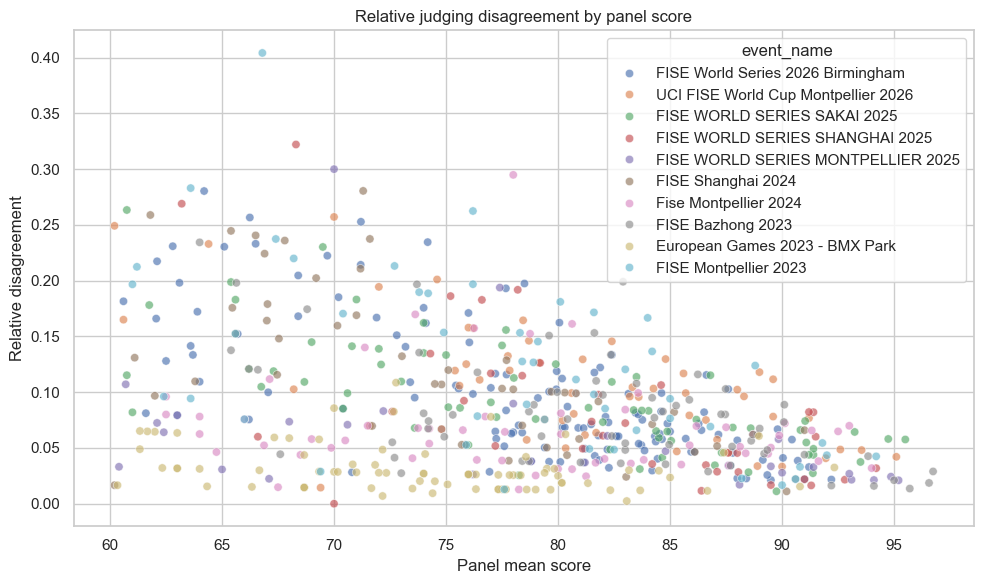

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=result,
    x="panel_mean",
    y="relative_disagreement",
    hue="event_name",
    alpha=0.65
)

plt.xlabel("Panel mean score")
plt.ylabel("Relative disagreement")
plt.title(
    "Relative judging disagreement by panel score"
)

plt.tight_layout()
plt.show()

In [124]:
analysis_df["round_clean"] = (
    analysis_df["round"]
    .astype(str)
    .str.strip()
    .str.upper()
)

analysis_df["round_type"] = np.where(
    analysis_df["round_clean"].str.contains(
        "SEMI|FINAL",
        na=False
    ),
    "final",
    "other"
)

analysis_df["round_type"].value_counts()

round_type
final    692
other    301
Name: count, dtype: int64

In [125]:
athlete_keys = [
    "event_id",
    "event_name",
    "contest",
    "category",
    "round",
    "round_type",
    "athlete_id",
    "athlete"
]

athlete_scores = (
    analysis_df
    .groupby(athlete_keys)
    .agg(
        n_runs=("run", "nunique"),
        run_scores=("run_score", list),
        official_rank=("rank", "first"),
        total=("total", "first")
    )
    .reset_index()
)

In [126]:
athlete_scores["calculated_score"] = np.where(
    athlete_scores["round_type"].eq("final"),

    # Final = meilleur des 2 runs
    athlete_scores["run_scores"].apply(max),

    # Autres rounds = moyenne des 2 runs
    athlete_scores["run_scores"].apply(np.mean)
)

In [131]:
ranking_keys = [
    "event_name",
    "contest",
    "category",
    "round"
]

athlete_scores["calculated_rank"] = (
    athlete_scores
    .groupby(ranking_keys)["total"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [132]:
athlete_scores["rank_difference"] = (
    athlete_scores["calculated_rank"]
    - athlete_scores["official_rank"]
)

athlete_scores["rank_match"] = (
    athlete_scores["rank_difference"] == 0
)

In [133]:
rank_accuracy = (
    athlete_scores["rank_match"]
    .mean()
)

print(
    f"Agreement between official rank and "
    f"calculated rank: {rank_accuracy:.2%}"
)

Agreement between official rank and calculated rank: 100.00%


In [140]:
judge_positions = ["J1", "J2", "J3", "J4", "J5"]

for judge in judge_positions:

    other_judges = [
        f"{j}_score"
        for j in judge_positions
        if j != judge
    ]

    analysis_df[
        f"run_score_without_{judge}"
    ] = (
        analysis_df[other_judges]
        .mean(axis=1)
    )

In [141]:
for judge in judge_positions:

    score_column = (
        f"run_score_without_{judge}"
    )

    total_column = (
        f"total_without_{judge}"
    )

    simulated_total = (
        analysis_df
        .groupby(athlete_keys)[score_column]
        .agg(
            lambda x: (
                x.max()
                if x.name is None
                else x.mean()
            )
        )
    )

In [148]:
def calculate_athlete_score(group, score_column):

    scores = group[score_column].dropna()

    if scores.empty:
        return np.nan

    if group["round_type"].iloc[0] == "final":
        return scores.max()

    return scores.mean()

In [149]:
for judge in judge_positions:

    score_column = (
        f"run_score_without_{judge}"
    )

    total_column = (
        f"total_without_{judge}"
    )

    simulated_totals = (
        analysis_df
        .groupby(athlete_keys)
        .apply(
            lambda group:
                calculate_athlete_score(
                    group,
                    score_column
                )
        )
        .rename(total_column)
        .reset_index()
    )

    athlete_scores = athlete_scores.merge(
        simulated_totals,
        on=athlete_keys,
        how="left"
    )

C:\Users\USER\AppData\Local\Temp\ipykernel_13948\2380451484.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\USER\AppData\Local\Temp\ipykernel_13948\2380451484.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\USER\AppData\Local\Temp\ipykernel_13948\2380451484.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

In [151]:
for judge in judge_positions:

    total_column = (
        f"total_without_{judge}"
    )

    rank_column = (
        f"rank_without_{judge}"
    )

    athlete_scores[rank_column] = (
        athlete_scores
        .groupby(ranking_keys)[total_column]
        .rank(
            ascending=False,
            method="min"
        )
    )

In [152]:
for judge in judge_positions:

    athlete_scores[
        f"rank_change_without_{judge}"
    ] = (
        athlete_scores[
            f"rank_without_{judge}"
        ]
        - athlete_scores["official_rank"]
    )

    athlete_scores[
        f"abs_rank_change_without_{judge}"
    ] = (
        athlete_scores[
            f"rank_change_without_{judge}"
        ]
        .abs()
    )

In [153]:
sensitivity = []

for judge in judge_positions:

    changes = athlete_scores[
        f"abs_rank_change_without_{judge}"
    ]

    sensitivity.append({
        "judge": judge,
        "mean_abs_rank_change": changes.mean(),
        "median_abs_rank_change": changes.median(),
        "max_rank_change": changes.max(),
        "pct_athletes_rank_changed": (
            (changes > 0).mean() * 100
        ),
        "pct_athletes_changed_2plus": (
            (changes >= 2).mean() * 100
        )
    })

sensitivity_df = pd.DataFrame(sensitivity)

sensitivity_df


,judge,mean_abs_rank_change,median_abs_rank_change,max_rank_change,pct_athletes_rank_changed,pct_athletes_changed_2plus
0,J1,0.748,0.0,18.0,29.2,10.8
1,J2,0.652,0.0,17.0,26.6,8.6
2,J3,0.626,0.0,17.0,24.0,8.0
3,J4,0.658,0.0,18.0,23.8,9.0
4,J5,0.636,0.0,18.0,21.6,9.8


In [173]:
# Garder uniquement le run qui compte pour chaque athlète en finale
final_runs = (
    analysis_df[
        analysis_df["round"] == "Final"
    ]
    .copy()
)

final_runs["run_score"] = pd.to_numeric(
    final_runs["run_score"],
    errors="coerce"
)

best_run_detail = (
    final_runs
    .sort_values(
        [
            "event_name",
            "contest",
            "category",
            "round",
            "athlete_id",
            "run_score"
        ],
        ascending=[True, True, True, True, True, False]
    )
    .drop_duplicates(
        subset=[
            "event_name",
            "contest",
            "category",
            "round",
            "athlete_id"
        ],
        keep="first"
    )
)

In [174]:
best_run_detail = best_run_detail[
    [
        "event_name",
        "contest",
        "category",
        "round",
        "athlete_id",
        "run",
        "run_score",
        "J1_score",
        "J2_score",
        "J3_score",
        "J4_score",
        "J5_score"
    ]
]

In [175]:
top20_with_judges = (
    top20_changes
    .merge(
        best_run_detail,
        on=[
            "event_name",
            "contest",
            "category",
            "round",
            "athlete_id"
        ],
        how="left"
    )
)

In [177]:
top20_with_judges[
    [
        "event_name",
        "contest",
        "category",
        "round",
        "athlete",
        "judge_removed",

        "official_rank",
        "rank_without_judge",
        "rank_change",

        "total",
        "total_without_judge",

        "run",
        "run_score",

        "J1_score",
        "J2_score",
        "J3_score",
        "J4_score",
        "J5_score"
    ]
].head(20)


,event_name,contest,category,round,athlete,judge_removed,official_rank,rank_without_judge,rank_change,total,total_without_judge,run,run_score,J1_score,J2_score,J3_score,J4_score,J5_score
0,FISE Montpellier 2023,UCI BMX FREESTYLE PARK WC WOMEN,Default,Final,Lara LESSMANN,J3,9,11.0,2.0,66.80,63.750000,Run 1,66.80,52.0,64.0,79.0,70.0,69.0
1,UCI FISE World Cup Montpellier 2026,UCI BMX Freestyle Park World Cup Men,Default,Final,Kenneth TENCIO,J3,7,5.0,-2.0,86.60,87.250000,Run 2,86.60,87.5,89.0,84.0,83.0,89.5
2,FISE WORLD SERIES SHANGHAI 2025,UCI BMX Freestyle Park World Cup Men,Default,Final,Kaine MITCHELL,J1,15,17.0,2.0,77.20,77.000000,Run 1,77.20,78.0,78.0,78.0,74.0,78.0
3,FISE WORLD SERIES SHANGHAI 2025,UCI BMX Freestyle Park World Cup Men,Default,Final,Kaine MITCHELL,J2,15,17.0,2.0,77.20,77.000000,Run 1,77.20,78.0,78.0,78.0,74.0,78.0
4,FISE WORLD SERIES SHANGHAI 2025,UCI BMX Freestyle Park World Cup Men,Default,Final,Kaine MITCHELL,J4,15,13.0,-2.0,77.20,78.000000,Run 1,77.20,78.0,78.0,78.0,74.0,78.0
5,FISE WORLD SERIES SHANGHAI 2025,UCI BMX Freestyle Park World Cup Men,Default,Final,Kevin PERAZA,J5,10,12.0,2.0,81.80,81.250000,Run 2,81.80,76.0,82.5,83.0,83.5,84.0
6,UCI FISE World Cup Montpellier 2026,UCI BMX Freestyle Park World Cup Women,Default,Final,Shanshan LEI,J5,5,7.0,2.0,80.80,79.500000,Run 1,80.80,78.0,81.0,79.0,80.0,86.0
7,FISE WORLD SERIES SAKAI 2025,UCI BMX Freestyle Park World Cup Men,Default,Final,Anthony JEANJEAN,J1,4,5.0,1.0,91.20,90.750000,Run 1,91.20,93.0,91.0,89.0,90.0,93.0
8,FISE WORLD SERIES SAKAI 2025,UCI BMX Freestyle Park World Cup Men,Default,Final,Alec DANELUTTI,J1,5,4.0,-1.0,91.08,90.900000,Run 2,91.08,91.8,90.1,88.5,91.5,93.5
9,European Games 2023 - BMX Park,Men´s BMX Freestyle Park,Default,Final,Zoltan UJVARY,J2,8,9.0,1.0,74.06,73.850000,Run 1,74.06,75.5,74.5,72.2,NaN,NaN
